# Basic Plotting

---

### Table of Contents
1. Introduction to Plotting
2. The `.plot()` Accessor and Line Plots
3. Common Plot Types
4. Displaying the Plots

---

## 1. Introduction to Plotting
- Data visualization is a critical part of data analysis for understanding trends,
  patterns, and outliers in your data.
- Pandas has a built-in `.plot()` accessor that makes creating simple plots
  directly from a DataFrame or Series very easy.
- IMPORTANT: Pandas' plotting functions are a convenient wrapper around the
  powerful `matplotlib` library. To use them, you must have matplotlib installed:
  `pip install matplotlib`

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt  # The primary plotting library in Python

# --- Setup: Load data and create a 'TotalPrice' column ---
DATA_FOLDER = "pandas_data"
file_path = os.path.join(DATA_FOLDER, "sample_sales_data.csv")

try:
    df = pd.read_csv(file_path, parse_dates=["OrderDate"])
    df["TotalPrice"] = df["Price"] * df["Quantity"]
    print("--- Sample DataFrame for Plotting ---")
    print(df)
except FileNotFoundError:
    print(f"Error: The data file was not found at '{file_path}'")
    print("Please run '04_reading_and_writing_data.py' first to create it.")
    df = pd.DataFrame()  # Create an empty df to avoid further errors

--- Sample DataFrame for Plotting ---
   OrderID   Product     Category   Price  Quantity  OrderDate  TotalPrice
0      101    Laptop  Electronics  1200.0         1 2025-01-15      1200.0
1      102     Mouse  Electronics    25.5         2 2025-01-15        51.0
2      103  Keyboard  Electronics    75.0         1 2025-01-16        75.0
3      104   Monitor  Electronics   300.0         2 2025-01-17       600.0
4      105     Mouse  Accessories    27.0         3 2025-01-18        81.0
5      106    Webcam  Accessories    50.0         1 2025-01-18        50.0



---

## 2. The `.plot()` Accessor and Line Plots
- The `.plot()` method is the main interface for creating plots.
- The `kind` parameter specifies the type of plot. The default is a line plot.
- Line plots are best for visualizing data over a continuous interval, like time.

In [4]:
# To make a meaningful line plot, let's group sales by date
daily_revenue = df.groupby(by="OrderDate")["TotalPrice"].sum()
print("Aggregated daily revenue for line plot:\n", daily_revenue)

Aggregated daily revenue for line plot:
 OrderDate
2025-01-15    1251.0
2025-01-16      75.0
2025-01-17     600.0
2025-01-18     131.0
Name: TotalPrice, dtype: float64


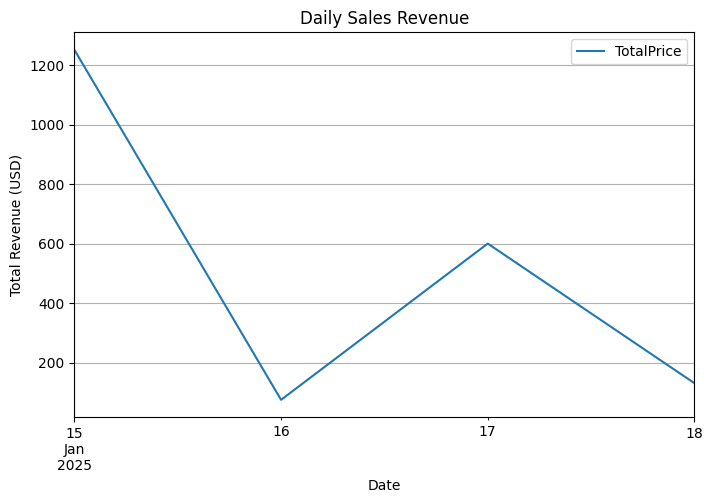


Generated a line plot for daily sales revenue.


In [5]:
# Create a line plot
daily_revenue.plot(
    kind="line",
    title="Daily Sales Revenue",
    xlabel="Date",
    ylabel="Total Revenue (USD)",
    figsize=(8, 5),  # Set the figure size (width, height in inches)
    grid=True,
    legend=True,
)
plt.show()  # In a script, this command displays the plot. We'll call it once at the end.
print("\nGenerated a line plot for daily sales revenue.")


---

## 3. Common Plot Types
- You can create many different types of plots by changing the `kind` parameter.

### 3.1. Bar Plot (`kind='bar'`)
- Good for comparing quantities across different categories.

Generated a bar plot for product quantities.


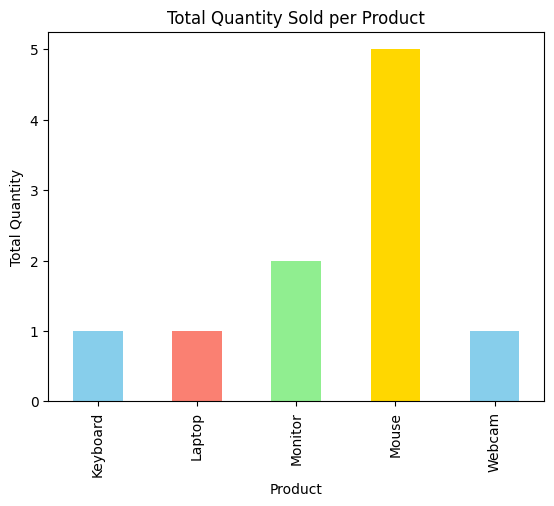

In [6]:
product_quantity = df.groupby("Product")["Quantity"].sum()
product_quantity.plot(
    kind="bar",
    title="Total Quantity Sold per Product",
    xlabel="Product",
    ylabel="Total Quantity",
    color=["skyblue", "salmon", "lightgreen", "gold"],  # You can specify colors
)
print("Generated a bar plot for product quantities.")
plt.show()

### 3.2. Histogram (`kind='hist'`)
- Good for understanding the distribution of a single numerical variable.

Generated a histogram for product prices.


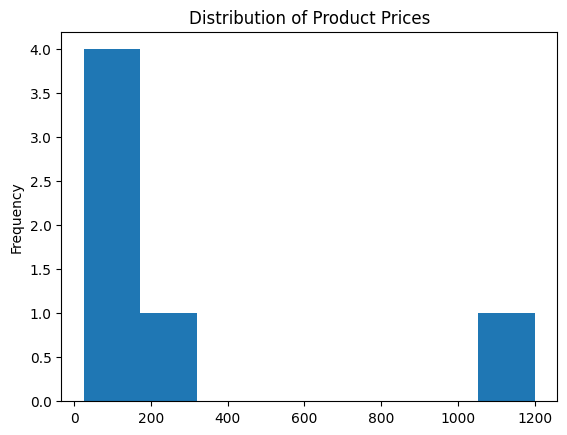

In [7]:
df["Price"].plot(
    kind="hist",
    title="Distribution of Product Prices",
    bins=8,  # The number of bars in the histogram
)
print("Generated a histogram for product prices.")
plt.show()

### 3.3. Scatter Plot (`kind='scatter'`) 
- Good for visualizing the relationship between two numerical variables.
- Requires specifying the x and y columns.

Generated a scatter plot for price vs. total revenue.
------------------------------


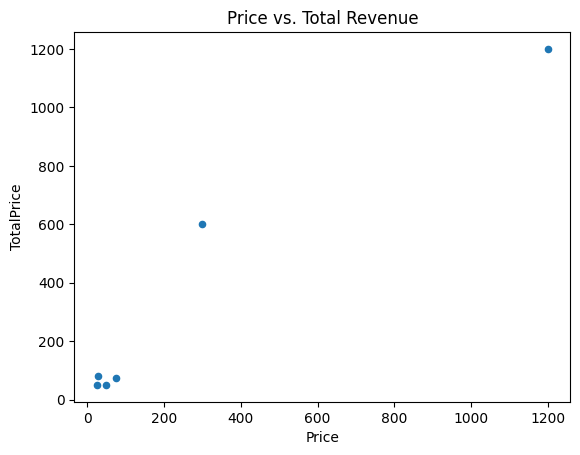

In [8]:
df.plot(kind="scatter", x="Price", y="TotalPrice", title="Price vs. Total Revenue")
print("Generated a scatter plot for price vs. total revenue.")
print("-" * 30)
plt.show()


### 4. Displaying the Plots
- When running a Python script, plots are created in the background.
- To actually see them, you must call `plt.show()`.
- This command opens an interactive window to display all the plots you've created.
- In environments like Jupyter Notebook, plots often appear automatically ("inline").

Here's an example code to run within a Python script:

In [ ]:
print("--- Displaying Plots ---")
print("Calling `plt.show()` to display all generated plots...")
print("Close the plot window(s) to end the script.")
plt.tight_layout()  # Adjusts plots to prevent labels from overlapping
plt.show()